# CIFAR-10 benchmark on OpenAI's iDDPM (AMG's model)

Writes `results/screen_ranked.csv`, `results/per_seed.csv`, `all_figures/cifar10_openai_memorized.pdf`, `all_figures/cifar10_openai_memorized_main.pdf` and `all_figures/cifar10_openai_non_memorized.pdf`.

In [1]:
import json, os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/guidance").exists())
sys.path.insert(0, str(ROOT / "src"))
from baselines import amg_paper, broken_memories as bm
from models import iddpm as I
from plotting import wsstyle

EXP = ROOT / "experiments/cifar10_openai"
CACHE, RESULTS = EXP / "cache", EXP / "results"
CACHE.mkdir(exist_ok=True); RESULTS.mkdir(exist_ok=True)
# from 00_parameter_tuning.ipynb
fr_file = json.loads((CACHE / "fr_settings.json").read_text())
FR_SETTINGS = {k: fr_file[k] for k in I.FR_SETTINGS}
# dirichlet_alpha set by hand, not tuned
BAYES_FR_SETTINGS = {**FR_SETTINGS, "dirichlet_alpha": 3}

device = os.environ.get("DEVICE") or ("mps" if torch.backends.mps.is_available() else "cpu")
config = {
    "screen_seeds": list(range(2000)), "screen_batch": 25,
    "memorized_seeds": [1755, 1527, 209, 1635, 542],
    "non_memorized_seeds": [34, 40, 86, 89, 92], "non_memorized_pool": list(range(100)),
    "amg_c_sweep": [0.3, 1, 3, 10],
    # BM: "paper" and tau-scale rows keep k=10; the k sweep spans 250 steps (paper: k=10 of 50)
    "bm_calibration_seeds": list(range(100, 140)), "bm_std_floor": 1e-5,
    "bm_threshold_scales": [1.0, 0.5, 0.25, 0.1],
    "bm_durations": [12, 50, 125, 250],            # at threshold scale 0.1
    "bm_projection_widths": [2.0, 1.0, 0.5],       # at threshold scale 0.1, k = 250
}
shown = set(config["memorized_seeds"] + config["non_memorized_seeds"])
assert not shown & set(sum(fr_file["tuned_on"].values(), [])), "FR was tuned on a seed shown here"
METHODS = ["unguided", "fr", "bayesian_fr", "random", "amg", "bm"]
LABELS = {m: wsstyle.METHOD_LABELS[m] for m in METHODS}
CLASSES = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

model = I.load(device)
train, labels, N_STEPS = model["train"], model["labels"], model["n_steps"]
print(f"device={device}, training images={tuple(train.shape)}, {N_STEPS} sampling steps, variance {model['diffusion'].model_var_type}")

device=mps, training images=(50000, 3, 32, 32), 250 sampling steps, variance ModelVarType.LEARNED_RANGE


## Model and samplers

OpenAI's `improved-diffusion` code, 250-step ancestral sampler, per-seed noise; AMG in its DDPM form (Supp. Eq. 22).

## Screen

Unguided samples for 2000 seeds, scored against all 50k training images (nL2 < 1.4 is memorized).

In [2]:
def to_img(x):
    return ((x.reshape(3, 32, 32) + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()

SCREEN = CACHE / "screen.pt"
screen_signature = {"version": 2, "device": device, "code": I.COMMIT, "flags": I.FLAGS,
                    "noise": "SeedNoise: cpu Generator, x_T then one draw per step"}
screen_cache = torch.load(SCREEN, map_location="cpu", weights_only=False) if SCREEN.exists() else {}
if screen_cache.get("signature") != screen_signature:
    screen_cache = {"signature": screen_signature, "x": {}}
todo = [s for s in config["screen_seeds"] if s not in screen_cache["x"]]
for b in range(0, len(todo), config["screen_batch"]):
    batch = todo[b:b + config["screen_batch"]]
    t0 = time.perf_counter()
    screen_cache["x"].update(zip(batch, [r["x"][0] for r in I.unguided(model, batch)]))
    torch.save(screen_cache, SCREEN)
    print(f"seeds {batch[0]}-{batch[-1]}: {(time.perf_counter() - t0) / len(batch):.1f}s/sample, "
          f"{b + len(batch)}/{len(todo)}", flush=True)
screened = screen_cache["x"]

X_screen = torch.stack([screened[s] for s in config["screen_seeds"]])
nl2_s, ratio_s, nn_s = I.nl2_and_ratio(model, I.pack(X_screen))
screen = pd.DataFrame({"seed": config["screen_seeds"], "nl2": nl2_s.numpy(), "ratio": ratio_s.numpy(), "nn_idx": nn_s.numpy()})
screen["d1"] = (I.pack(X_screen) - I.pack(train[screen.nn_idx.values])).pow(2).mean(1).sqrt().numpy()
screen["nn_label"] = [CLASSES[int(labels[i])] for i in screen.nn_idx]
screen["mean_rank"] = screen[["nl2", "ratio"]].rank(method="min").mean(axis=1)
screen = screen.sort_values("mean_rank").reset_index(drop=True)
screen.to_csv(RESULTS / "screen_ranked.csv", index=False)
print(f"{len(screen)} samples: nL2 < {I.NL2_THRESHOLD}: {(screen.nl2 < I.NL2_THRESHOLD).sum()}, "
      f"d1/d2 < 1/2: {(screen.ratio < 0.5).sum()}")
#display(screen.head(20).round(3))

2000 samples: nL2 < 1.4: 12, d1/d2 < 1/2: 0


/var/folders/40/5q8m5t5x4v9f4d3735y7zr3r0000gn/T/ipykernel_52919/811536149.py:23: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  screen["d1"] = (I.pack(X_screen) - I.pack(train[screen.nn_idx.values])).pow(2).mean(1).sqrt().numpy()


## Seeds

Memorized: near-copies picked by eye. Non-memorized: sharp, clearly novel samples from seeds 0-99 (nL2 ≥ 1.6, $d_1/d_2 > 0.9$), picked by eye.

In [3]:
def sharpness(x):
    grey = ((x.reshape(3, 32, 32) + 1) / 2).mean(0)
    lap = grey[:-2, 1:-1] + grey[2:, 1:-1] + grey[1:-1, :-2] + grey[1:-1, 2:] - 4 * grey[1:-1, 1:-1]
    return lap.var().item()

pool = screen[screen.seed.isin(config["non_memorized_pool"])].copy()
assert not (pool.nl2 < I.NL2_THRESHOLD).any()
pool["sharpness"] = [sharpness(screened[s]) for s in pool.seed]
candidates = pool[(pool.nl2 >= 1.6) & (pool.ratio > 0.9)].sort_values("sharpness", ascending=False).head(24)
#display(candidates.round(3))

seed_rows = screen.set_index("seed").loc[config["memorized_seeds"] + config["non_memorized_seeds"]]
#display(seed_rows[["nl2", "ratio", "d1", "nn_idx", "nn_label"]].round(3))
base_nn = seed_rows.nn_idx.to_dict()

## Cache

In [4]:
def run_key(method, seed, **setting):
    if method == "unguided":
        return f"unguided|seed={seed}"
    if method in ("fr", "bayesian_fr", "random"):
        fr_setting = BAYES_FR_SETTINGS if method == "bayesian_fr" else FR_SETTINGS
        return f"{method}|seed={seed}|" + "|".join(f"{k}={v}" for k, v in fr_setting.items())
    s = {**config.get(method, {}), **setting}
    if method == "amg":
        return f"amg-paper-ddpm|seed={seed}|c={s['c']:g}"
    return f"bm|seed={seed}|scale={s['threshold_scale']:g}|k={s['mild_steps']}|gamma={s['gamma']:g}"

SAMPLERS = {
    "unguided": lambda seed, s: I.unguided(model, [seed])[0],
    "fr": lambda seed, s: I.fr(model, [seed], settings=FR_SETTINGS)[0],
    "bayesian_fr": lambda seed, s: I.fr(model, [seed], bayesian=True, settings=BAYES_FR_SETTINGS)[0],
    "random": lambda seed, s: I.random(model, [seed], settings=FR_SETTINGS)[0],
    "amg": lambda seed, s: I.amg(model, [seed], s["c"])[0],
    "bm": lambda seed, s: I.broken_memories(model, [seed], bm_stats, s["threshold_scale"], s["mild_steps"], s["gamma"])[0],
}

CACHE_FILE = CACHE / "benchmark.pt"
signature = {"version": 2, "screen": screen_signature,
             "amg": {"form": "ddpm mean shift (Supp. Eq. 22)",
                     "schedule": [amg_paper.SCHEDULE_A, amg_paper.SCHEDULE_B, amg_paper.SCHEDULE_C]},
             "bm_calibration": {"seeds": config["bm_calibration_seeds"], "std_floor": config["bm_std_floor"]}}
cache = torch.load(CACHE_FILE, map_location="cpu", weights_only=False) if CACHE_FILE.exists() else {}
if cache.get("signature") != signature:
    cache = {"signature": signature, "runs": {}}

def run(method, seed, **setting):
    """Cached run; `setting` overrides the method's operating point in config[method]."""
    key = run_key(method, seed, **setting)
    if key not in cache["runs"]:
        start = time.perf_counter()
        result = SAMPLERS[method](seed, {**config.get(method, {}), **setting})
        result["seconds"] = time.perf_counter() - start
        cache["runs"][key] = result
        torch.save(cache, CACHE_FILE)
    return cache["runs"][key]

def memorization(x):
    return I.memorization(model, x)[0]

## Broken Memories calibration

From non-memorized unguided trajectories of seeds 100-139.

In [5]:
for seed in config["memorized_seeds"] + config["non_memorized_seeds"]:
    assert seed not in config["bm_calibration_seeds"], f"seed {seed} calibrates Broken Memories"
if "bm_stats" not in cache:
    normal, rows = [], []
    seeds = config["bm_calibration_seeds"]
    for b in range(0, len(seeds), 20):
        endpoints, traces = I.norm_traces(model, seeds[b:b + 20])
        for k, seed in enumerate(seeds[b:b + 20]):
            nl2 = memorization(endpoints[k:k + 1])["nl2"]
            rows.append({"seed": seed, "nl2": nl2, "normal": nl2 >= I.NL2_THRESHOLD})
            if rows[-1]["normal"]:
                normal.append({name: v[k] for name, v in traces.items()})
    assert len(normal) >= 20, f"only {len(normal)} normal calibration trajectories"
    cache["bm_stats"] = bm.calibrate({name: torch.stack([t[name] for t in normal]) for name in bm.NORMS},
                                     std_floor=config["bm_std_floor"])
    cache["bm_calibration_table"] = pd.DataFrame(rows)
    torch.save(cache, CACHE_FILE)
bm_stats = cache["bm_stats"]
calibration = cache["bm_calibration_table"]
print(f"{int(calibration.normal.sum())} of {len(calibration)} calibration trajectories are non-memorized")

40 of 40 calibration trajectories are non-memorized


## Operating points

AMG: smallest $c$ escaping the most memorized seeds. Broken Memories: highest mean $d_1/d_2$, ties to the earlier sweep entry.

In [6]:
BM_SWEEP = ([{"name": "paper" if s == 1 else f"tau-scale={s:g}", "threshold_scale": s, "mild_steps": 10, "gamma": 3.0}
             for s in config["bm_threshold_scales"]]
            + [{"name": f"k={k}", "threshold_scale": 0.1, "mild_steps": k, "gamma": 3.0} for k in config["bm_durations"]]
            + [{"name": f"gamma={g:g}", "threshold_scale": 0.1, "mild_steps": N_STEPS, "gamma": g}
               for g in config["bm_projection_widths"]])

def scores_of(result):
    r = memorization(result["x"])
    return r["nl2"], r["ratio"]

amg_sweep = pd.DataFrame([{"c": c, "seed": seed, "nl2": scores_of(run("amg", seed, c=c))[0],
                           "ratio": scores_of(run("amg", seed, c=c))[1],
                           "active_steps": int(run("amg", seed, c=c)["active"].sum())}
                          for c in config["amg_c_sweep"] for seed in config["memorized_seeds"]])
amg_summary = (amg_sweep.assign(escaped=amg_sweep.nl2 >= I.NL2_THRESHOLD)
               .groupby("c").agg(n_escaped=("escaped", "sum"), mean_nl2=("nl2", "mean"), mean_ratio=("ratio", "mean"),
                                 mean_active_steps=("active_steps", "mean")))
config["amg"] = {"c": float(amg_summary.index[amg_summary.n_escaped.eq(amg_summary.n_escaped.max())].min())}

bm_sweep = pd.DataFrame([{**s, "mean_ratio": np.mean([scores_of(run("bm", seed, **{k: s[k] for k in ["threshold_scale", "mild_steps", "gamma"]}))[1]
                                                      for seed in config["memorized_seeds"]]),
                          "mean_active_steps": np.mean([int(run("bm", seed, **{k: s[k] for k in ["threshold_scale", "mild_steps", "gamma"]})["active"].sum())
                                                        for seed in config["memorized_seeds"]])} for s in BM_SWEEP])
best = bm_sweep.loc[bm_sweep.mean_ratio.round(4).idxmax()]   # first maximum in sweep order
config["bm"] = {"threshold_scale": float(best.threshold_scale), "mild_steps": int(best.mild_steps), "gamma": float(best.gamma)}

(CACHE / "operating_points.json").write_text(json.dumps({"amg": config["amg"], "bm": config["bm"]}, indent=1))
display(amg_summary.round(3))
display(bm_sweep.round(3))
print(f"AMG: c={config['amg']['c']:g}")
print(f"Broken Memories: {best['name']} (threshold scale={config['bm']['threshold_scale']:g}, "
      f"k={config['bm']['mild_steps']}, gamma={config['bm']['gamma']:g})")

,n_escaped,mean_nl2,mean_ratio,mean_active_steps
c,,,,
0.3,1,1.240,0.859,249.0
1.0,2,1.444,0.879,236.8
3.0,5,1.678,0.945,219.2
10.0,5,1.818,0.984,198.8


,name,threshold_scale,mild_steps,gamma,mean_ratio,mean_active_steps
0,paper,1.00,10,3.0,0.845,0.0
1,tau-scale=0.5,0.50,10,3.0,0.843,0.6
2,tau-scale=0.25,0.25,10,3.0,0.880,5.4
3,tau-scale=0.1,0.10,10,3.0,0.936,82.2
4,k=12,0.10,12,3.0,0.955,83.2
5,k=50,0.10,50,3.0,0.987,100.4
6,k=125,0.10,125,3.0,0.985,135.0
7,k=250,0.10,250,3.0,0.987,194.6
8,gamma=2,0.10,250,2.0,0.987,194.6
9,gamma=1,0.10,250,1.0,0.987,194.6


AMG: c=3
Broken Memories: gamma=1 (threshold scale=0.1, k=250, gamma=1)


## Run

In [7]:
SEED_GROUPS = {"memorized": config["memorized_seeds"], "non-memorized": config["non_memorized_seeds"]}
for group, seeds in SEED_GROUPS.items():
    for seed in seeds:
        for method in METHODS:
            result = run(method, seed)
            m = memorization(result["x"])
            print(f"{group:<13} seed={seed:>4} {LABELS[method]:<20} nL2={m['nl2']:.3f} ratio={m['ratio']:.3f} "
                  f"active steps={int(result['active'].sum()):>3} ({result['seconds']:.0f}s)")

memorized     seed=1755 Unguided             nL2=1.061 ratio=0.962 active steps=  0 (7s)
memorized     seed=1755 FR                   nL2=1.749 ratio=0.999 active steps=226 (38s)


memorized     seed=1755 Bayesian FR          nL2=1.818 ratio=0.998 active steps=226 (37s)


memorized     seed=1755 Random perturbations nL2=1.099 ratio=0.970 active steps=226 (7s)
memorized     seed=1755 AMG                  nL2=1.891 ratio=0.979 active steps=159 (29s)


memorized     seed=1755 Broken Memories      nL2=1.822 ratio=0.999 active steps=194 (12s)


memorized     seed=1527 Unguided             nL2=1.169 ratio=0.834 active steps=  0 (7s)
memorized     seed=1527 FR                   nL2=1.846 ratio=1.000 active steps=226 (35s)
memorized     seed=1527 Bayesian FR          nL2=1.875 ratio=0.999 active steps=226 (36s)


...

non-memorized seed=  89 FR                   nL2=1.664 ratio=1.000 active steps=226 (35s)


non-memorized seed=  89 Bayesian FR          nL2=1.936 ratio=1.000 active steps=226 (39s)
non-memorized seed=  89 Random perturbations nL2=1.818 ratio=0.988 active steps=226 (7s)
non-memorized seed=  89 AMG                  nL2=1.782 ratio=0.993 active steps=206 (29s)


non-memorized seed=  89 Broken Memories      nL2=1.814 ratio=0.979 active steps=192 (13s)


non-memorized seed=  92 Unguided             nL2=1.844 ratio=0.996 active steps=  0 (7s)
non-memorized seed=  92 FR                   nL2=1.764 ratio=1.000 active steps=226 (40s)
non-memorized seed=  92 Bayesian FR          nL2=1.769 ratio=1.000 active steps=226 (38s)


non-memorized seed=  92 Random perturbations nL2=1.845 ratio=0.996 active steps=226 (8s)
non-memorized seed=  92 AMG                  nL2=1.835 ratio=0.986 active steps=201 (29s)
non-memorized seed=  92 Broken Memories      nL2=1.802 ratio=0.951 active steps=186 (12s)


## Reproducibility against the screen

Unguided must match the screen; AMG with $c = 0$ must match unguided.

In [8]:
checks = pd.DataFrame([{"seed": seed,
                        "unguided vs screen": (run("unguided", seed)["x"][0] - screened[seed]).abs().max().item(),
                        "AMG c=0 vs unguided": (run("amg", seed, c=0.0)["x"] - run("unguided", seed)["x"]).abs().max().item()}
                       for seed in config["memorized_seeds"]])
display(checks.set_index("seed"))

,unguided vs screen,AMG c=0 vs unguided
seed,,
1755,8.344650e-07,0.0
1527,6.556511e-07,0.0
209,2.453476e-05,0.0
1635,1.460314e-06,0.0
542,7.748604e-07,0.0


## Per-seed results

`new_nn`: nearest training image differs from the unguided one. `displacement`: relative distance to the unguided sample.

In [9]:
rows = []
for group, seeds in SEED_GROUPS.items():
    for seed in seeds:
        x_base = run("unguided", seed)["x"]
        for method in METHODS:
            result = run(method, seed)
            m = memorization(result["x"])
            rows.append({"group": group, "seed": seed, "method": LABELS[method], **m, "new_nn": m["nn_idx"] != base_nn[seed],
                         "displacement": ((result["x"] - x_base).norm() / x_base.norm()).item(),
                         "active_steps": int(result["active"].sum()), "seconds": result["seconds"]})
results = pd.DataFrame(rows)
results.to_csv(RESULTS / "per_seed.csv", index=False)
for value in ["nl2", "ratio", "new_nn", "displacement", "active_steps"]:
    table = results.pivot_table(index=["group", "seed"], columns="method", values=value, sort=False)
    display(table[[LABELS[m] for m in METHODS]].round(3))

method              Unguided     FR  Bayesian FR  Random perturbations    AMG  \
group         seed                                                              
memorized     1755     1.061  1.749        1.818                 1.099  1.891   
              1527     1.169  1.846        1.875                 1.139  1.559   
              209      1.392  1.890        1.844                 1.399  1.627   
              1635     1.028  1.844        1.701                 1.035  1.761   
              542      1.371  1.414        1.856                 1.342  1.553   
non-memorized 34       1.843  1.856        1.913                 1.863  1.873   
              40       1.882  1.918        1.939                 1.884  1.910   
              86       1.891  1.738        1.873                 1.904  1.877   
              89       1.836  1.664        1.936                 1.818  1.782   
              92       1.844  1.764        1.769                 1.845  1.835   

method              Broken Memories  
group         seed                   
memorized     1755            1.822  
              1527            1.865  
              209             1.847  
              1635            1.795  
              542             1.802  
non-memorized 34              1.821  
              40              1.866  
              86              1.791  
              89              1.814  
              92              1.802

method              Unguided     FR  Bayesian FR  Random perturbations    AMG  \
group         seed                                                              
memorized     1755     0.962  0.999        0.998                 0.970  0.979   
              1527     0.834  1.000        0.999                 0.785  0.966   
              209      0.765  1.000        0.999                 0.765  0.904   
              1635     0.821  0.999        0.995                 0.812  0.964   
              542      0.845  0.998        1.000                 0.837  0.912   
non-memorized 34       0.998  0.999        1.000                 1.000  0.986   
              40       0.976  0.999        1.000                 0.979  0.997   
              86       0.992  0.999        1.000                 0.992  0.991   
              89       0.998  1.000        1.000                 0.988  0.993   
              92       0.996  1.000        1.000                 0.996  0.986   

method              Broken Memories  
group         seed                   
memorized     1755            0.999  
              1527            0.994  
              209             0.981  
              1635            0.994  
              542             0.968  
non-memorized 34              0.985  
              40              0.988  
              86              0.981  
              89              0.979  
              92              0.951

method              Unguided   FR  Bayesian FR  Random perturbations  AMG  \
group         seed                                                          
memorized     1755       0.0  1.0          1.0                   1.0  1.0   
              1527       0.0  1.0          1.0                   0.0  0.0   
              209        0.0  1.0          1.0                   0.0  0.0   
              1635       0.0  1.0          1.0                   0.0  1.0   
              542        0.0  1.0          1.0                   0.0  0.0   
non-memorized 34         0.0  1.0          1.0                   0.0  1.0   
              40         0.0  1.0          1.0                   0.0  0.0   
              86         0.0  1.0          1.0                   1.0  0.0   
              89         0.0  1.0          1.0                   0.0  1.0   
              92         0.0  1.0          1.0                   1.0  0.0   

method              Broken Memories  
group         seed                   
memorized     1755              1.0  
              1527              1.0  
              209               1.0  
              1635              1.0  
              542               1.0  
non-memorized 34                1.0  
              40                1.0  
              86                1.0  
              89                1.0  
              92                1.0

method              Unguided     FR  Bayesian FR  Random perturbations    AMG  \
group         seed                                                              
memorized     1755       0.0  0.885        1.020                 0.050  0.673   
              1527       0.0  0.852        0.884                 0.063  0.225   
              209        0.0  0.480        0.459                 0.063  0.195   
              1635       0.0  0.875        1.055                 0.041  0.920   
              542        0.0  0.448        0.739                 0.053  0.158   
non-memorized 34         0.0  0.701        1.051                 0.123  0.555   
              40         0.0  1.575        0.921                 0.117  0.287   
              86         0.0  0.901        0.726                 0.285  0.203   
              89         0.0  0.781        1.021                 0.171  0.577   
              92         0.0  1.082        1.082                 0.063  0.232   

method              Broken Memories  
group         seed                   
memorized     1755            0.618  
              1527            0.676  
              209             0.596  
              1635            0.989  
              542             0.569  
non-memorized 34              0.162  
              40              0.548  
              86              0.859  
              89              0.323  
              92              0.412

method              Unguided     FR  Bayesian FR  Random perturbations    AMG  \
group         seed                                                              
memorized     1755       0.0  226.0        226.0                 226.0  159.0   
              1527       0.0  226.0        226.0                 226.0  243.0   
              209        0.0  226.0        226.0                 226.0  236.0   
              1635       0.0  226.0        226.0                 226.0  214.0   
              542        0.0  226.0        226.0                 226.0  244.0   
non-memorized 34         0.0  226.0        226.0                 226.0  180.0   
              40         0.0  226.0        226.0                 226.0  157.0   
              86         0.0  226.0        226.0                 226.0  180.0   
              89         0.0  226.0        226.0                 226.0  206.0   
              92         0.0  226.0        226.0                 226.0  201.0   

method              Broken Memories  
group         seed                   
memorized     1755            194.0  
              1527            191.0  
              209             189.0  
              1635            194.0  
              542             205.0  
non-memorized 34              202.0  
              40              187.0  
              86              185.0  
              89              192.0  
              92              186.0

In [10]:
tiles = {}
for group, seeds in SEED_GROUPS.items():
    for seed in seeds:
        for method in METHODS:
            x = run(method, seed)["x"]
            tiles[(seed, method)] = {"gen": x.reshape(3, 32, 32), "nn": train[memorization(x)["nn_idx"]]}

## Figure: what each method generates

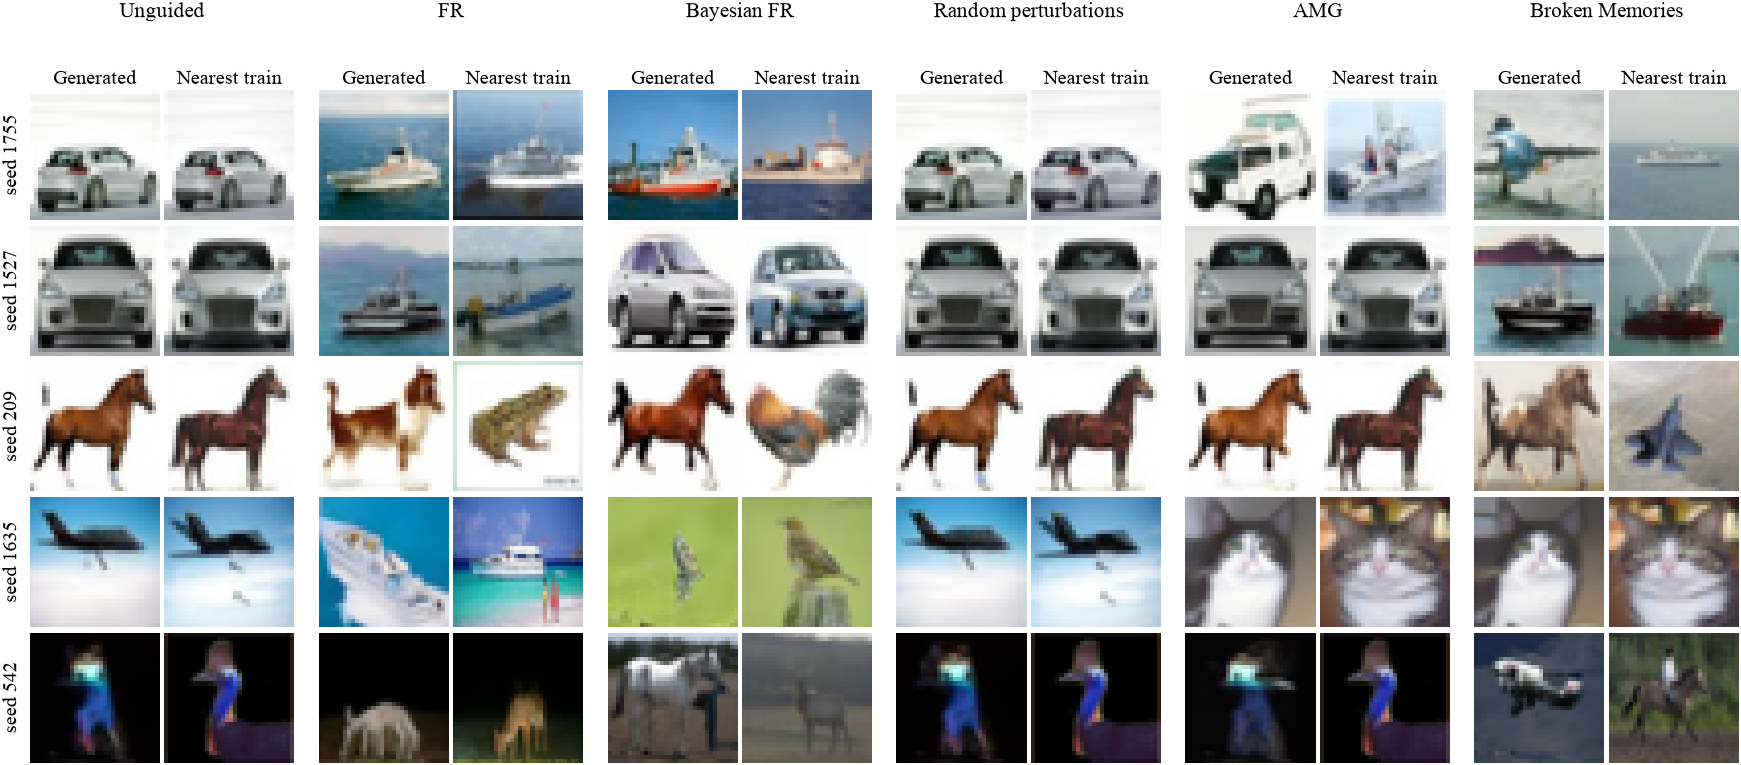

['all_figures/cifar10_openai_memorized.pdf']


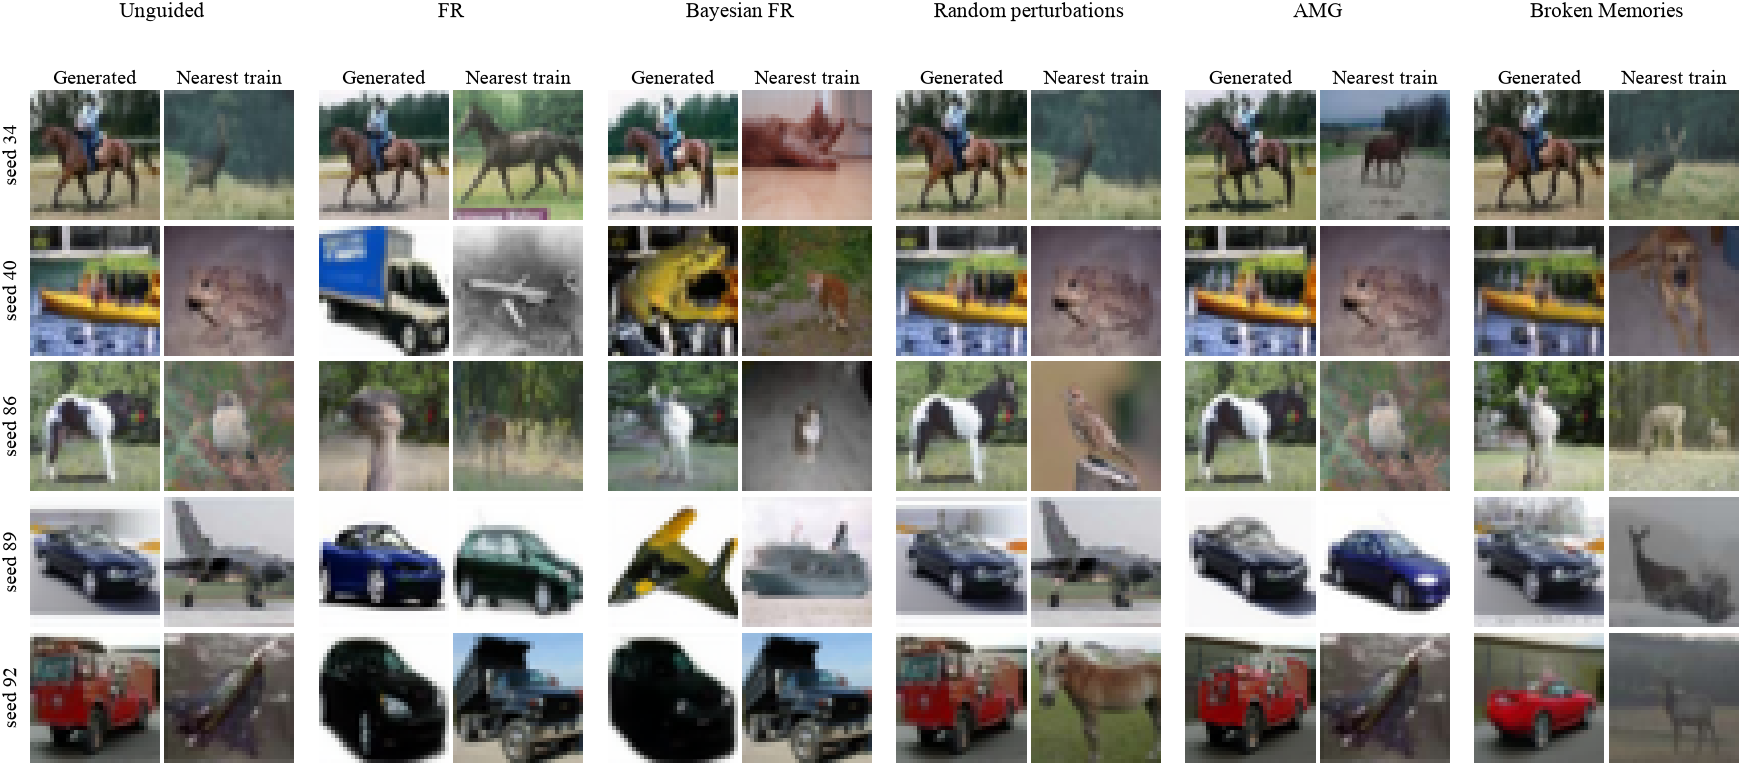

['all_figures/cifar10_openai_non_memorized.pdf']


In [11]:
wsstyle.paper_style()

def show(ax, image, edge):
    ax.imshow(to_img(image), interpolation="nearest")
    wsstyle.strip_axes(ax)

def draw_methods_figure(seeds, name):
    """One block per method (generated sample, nearest training image), one row per seed, at the paper's full width."""
    n_blocks, n_rows = len(METHODS), len(seeds)
    width, left, right, top, bottom = wsstyle.FULL_WIDTH, 0.42, 0.04, 0.92, 0.04
    tile_gap, block_gap, row_gap = 0.04, 0.22, 0.05
    tile = (width - left - right - n_blocks * tile_gap - (n_blocks - 1) * block_gap) / (2 * n_blocks)
    height = top + bottom + n_rows * tile + (n_rows - 1) * row_gap
    fig = plt.figure(figsize=(width, height))
    rect = lambda x, y: [x / width, 1 - (y + tile) / height, tile / width, tile / height]

    block_x = [left + b * (2 * tile + tile_gap + block_gap) for b in range(n_blocks)]
    for i, seed in enumerate(seeds):
        y = top + i * (tile + row_gap)
        for b, method in enumerate(METHODS):
            for j, kind in enumerate(["gen", "nn"]):
                ax = fig.add_axes(rect(block_x[b] + j * (tile + tile_gap), y))
                show(ax, tiles[(seed, method)][kind], "#7A7A7A" if kind == "gen" else "#D0D0D0")
                if i == 0:
                    ax.set_title(["Generated", "Nearest train"][j], fontsize=wsstyle.FONT_SIZE, pad=4)
                if b == 0 and j == 0:
                    ax.set_ylabel(f"seed {seed}", labelpad=6, fontsize=wsstyle.FONT_SIZE)

    for b, method in enumerate(METHODS):
        x0, x1 = block_x[b] / width, (block_x[b] + 2 * tile + tile_gap) / width
        fig.text(0.5 * (x0 + x1), 1 - 0.30 / height, LABELS[method], ha="center", va="bottom", fontsize=wsstyle.TITLE_SIZE)
    paths = wsstyle.save(fig, name)
    plt.show()
    return paths

for group in SEED_GROUPS:
    print(draw_methods_figure(SEED_GROUPS[group], f"cifar10_openai_{group.replace('-', '_')}"))

## Figure: main-body version

Same layout as the full grid above, restricted to three memorized seeds.

main-body seeds: [1635, 209, 1527]


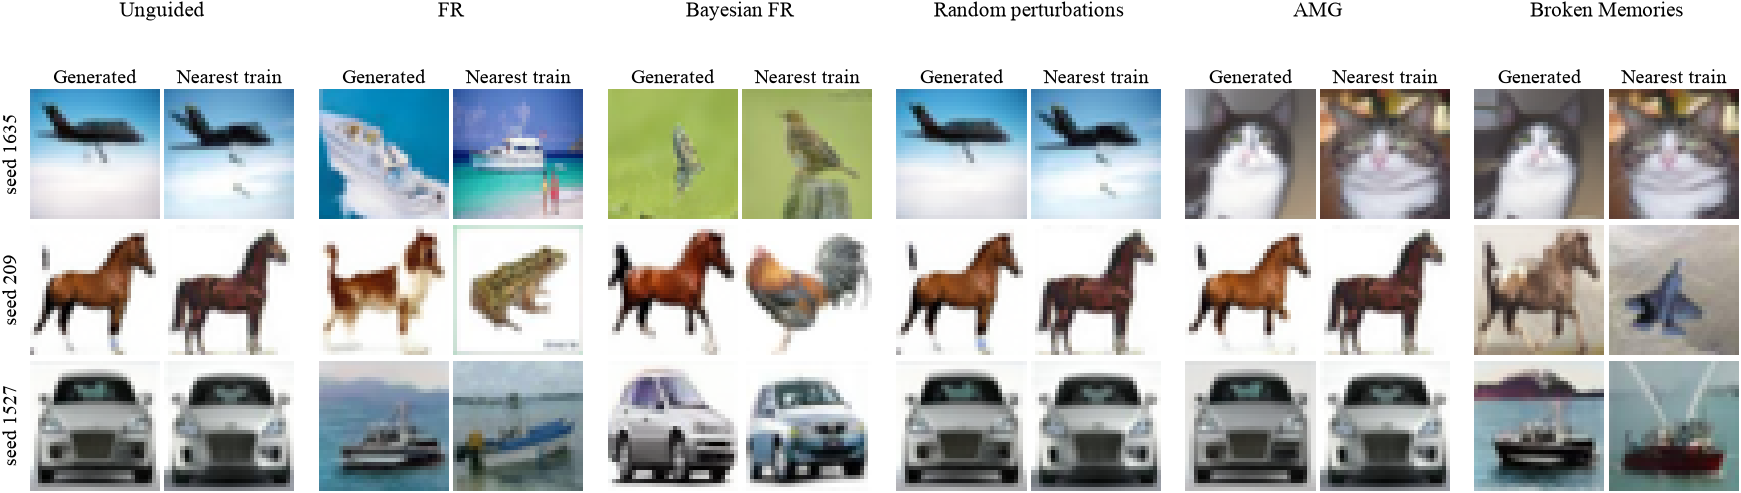

['all_figures/cifar10_openai_memorized_main.pdf']


In [12]:
# main body: three memorized seeds picked by hand for distinct classes (plane, horse, car); the full grids above go to the appendix
MAIN_SEEDS = [1635, 209, 1527]
assert set(MAIN_SEEDS) <= set(config["memorized_seeds"])
print("main-body seeds:", MAIN_SEEDS)
print(draw_methods_figure(MAIN_SEEDS, "cifar10_openai_memorized_main"))